<a href="https://colab.research.google.com/github/francji1/01NAEX/blob/main/code/01NAEX_Ex03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 01NAEX - Exercise 03: Randomized blocks and factorial designs

Data and exercises come from D. C. Montgomery: *Design and Analysis of Experiments*, 8th edition, Chapters 4 and 5.
Problem numbers follow the 8th edition.

## Learning goals

* Analyse a randomized complete block design (RCBD) in `statsmodels` and see what happens when the blocks are ignored.
* Quantify the benefit of blocking with the relative efficiency of the RCBD.
* Compare treatment means with Fisher's LSD and Tukey's HSD using the error mean square of the *correct* model.
* Fit and interpret a two-factor factorial model with interaction: interaction plots, ANOVA, simple effects, residual analysis.
* Test for nonadditivity when there is only one observation per cell (Tukey's one-degree-of-freedom test).
* Compute the power of the ANOVA $F$-test from the noncentral $F$ distribution and choose the number of blocks or replicates.
* Model a quantitative factor with response curves and surfaces; analyse a three-factor factorial and a factorial run in blocks.

## Setup

Run this cell first. Besides the standard imports it defines three small helper functions used throughout the notebook:

* `tukey_from_model()` - Tukey's HSD with $MS_E$ and $df_E$ taken from a fitted model with blocks or several factors.
  (`pairwise_tukeyhsd()` from `statsmodels` always fits a one-way model, so it uses the wrong error mean square in these designs.)
* `tukey_nonadditivity()` - Tukey's one-degree-of-freedom test for nonadditivity (one observation per cell).
* `anova_power()` - power of the ANOVA $F$-test for a given noncentrality parameter $\lambda$.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.graphics.factorplots import interaction_plot
from statsmodels.stats.multicomp import pairwise_tukeyhsd

URL = "https://raw.githubusercontent.com/francji1/01NAEX/main/data/"


def tukey_from_model(model, data, factor, response, alpha=0.05):
    """Tukey's HSD for the levels of `factor`, using MS_E and df_E of a fitted model.

    Balanced data are assumed (the same number of observations at every level of `factor`).
    """
    mse, dfe = model.mse_resid, model.df_resid
    means = data.groupby(factor, observed=True)[response].mean()
    n = data.groupby(factor, observed=True)[response].count().iloc[0]
    k = len(means)
    se = np.sqrt(mse / n)
    hsd = stats.studentized_range.ppf(1 - alpha, k, dfe) * se
    rows = []
    levels = list(means.index)
    for i in range(k):
        for j in range(i + 1, k):
            diff = means.iloc[j] - means.iloc[i]
            rows.append({"pair": f"{levels[j]} - {levels[i]}", "diff": diff,
                         "lower": diff - hsd, "upper": diff + hsd,
                         "p_adj": stats.studentized_range.sf(abs(diff) / se, k, dfe),
                         "reject": abs(diff) > hsd})
    print(f"MS_E = {mse:.4g}, df_E = {dfe:.0f}, n per level = {n}, HSD = {hsd:.4g}")
    return pd.DataFrame(rows)


def tukey_nonadditivity(data, response, row, col):
    """Tukey's one-degree-of-freedom test for nonadditivity in a two-way layout with one observation per cell.

    The covariate q = (row mean - grand mean) * (column mean - grand mean) is added to the additive model;
    its sequential sum of squares is SS_N (1 df) and the remaining residual is SS_Error.
    """
    d = data.copy()
    g = d[response].mean()
    d["q_nonadd"] = ((d.groupby(row)[response].transform("mean") - g)
                     * (d.groupby(col)[response].transform("mean") - g))
    fit = smf.ols(f"{response} ~ C({row}) + C({col}) + q_nonadd", data=d).fit()
    return sm.stats.anova_lm(fit, typ=1)


def anova_power(lam, df1, df2, alpha=0.05):
    """Power of the ANOVA F-test: P(F'(df1, df2, lam) > F_{1-alpha; df1, df2})."""
    return stats.ncf.sf(stats.f.ppf(1 - alpha, df1, df2), df1, df2, lam)

## 1. Lecture example: hardness testing experiment (RCBD)

Lecture 3 analysed the hardness testing experiment (Montgomery, Example 4.1, Table 4.3). A machine measures hardness by
pressing a tip into a metal test coupon. Four types of tips are compared; the coupons may differ, so each of the four
coupons is used as a **block** and all four tips are tested on every coupon in random order. The response is the
Rockwell C-scale reading minus 40.

The data set is small, so we type it in.

In [2]:
y = [[9.3, 9.4, 9.6, 10.0],     # tip 1, coupons 1-4
     [9.4, 9.3, 9.8, 9.9],      # tip 2
     [9.2, 9.4, 9.5, 9.7],      # tip 3
     [9.7, 9.6, 10.0, 10.2]]    # tip 4
hard = pd.DataFrame([(t + 1, c + 1, y[t][c]) for t in range(4) for c in range(4)],
                    columns=["Tip", "Coupon", "y"])
hard.pivot(index="Tip", columns="Coupon", values="y")

Coupon,1,2,3,4
Tip,,,,
1,9.3,9.4,9.6,10.0
2,9.4,9.3,9.8,9.9
3,9.2,9.4,9.5,9.7
4,9.7,9.6,10.0,10.2


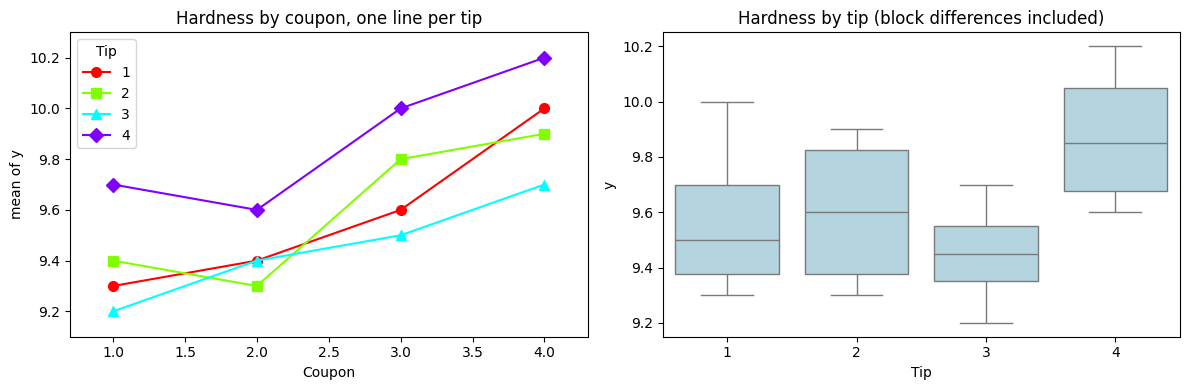

In [3]:
# Left: readings of each tip across the coupons (blocks); right: tips compared within coupons.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
interaction_plot(hard["Coupon"], hard["Tip"], hard["y"], ax=axes[0], markers=["o", "s", "^", "D"], ms=7)
axes[0].set_title("Hardness by coupon, one line per tip")
sns.boxplot(data=hard, x="Tip", y="y", ax=axes[1], color="lightblue")
axes[1].set_title("Hardness by tip (block differences included)")
plt.tight_layout(); plt.show()

The lines in the left plot are roughly parallel: the coupons shift all readings up or down by a similar amount
(block effect) and tip 4 reads highest on every coupon. The boxplot on the right mixes the coupon-to-coupon variability into
the spread of each tip, which hides the tip effect.

### ANOVA of the RCBD and the same data analysed as a completely randomized design

In [4]:
rcbd = smf.ols("y ~ C(Tip) + C(Coupon)", data=hard).fit()
crd = smf.ols("y ~ C(Tip)", data=hard).fit()
print("RCBD: tips + coupons (blocks)")
display(sm.stats.anova_lm(rcbd, typ=2))
print("CRD: blocks ignored")
display(sm.stats.anova_lm(crd, typ=2))
print(f"MS_E RCBD = {rcbd.mse_resid:.5f}, MS_E CRD = {crd.mse_resid:.5f}, ratio = {crd.mse_resid / rcbd.mse_resid:.2f}")

RCBD: tips + coupons (blocks)


,sum_sq,df,F,PR(>F)
C(Tip),0.385,3.0,14.4375,0.000871
C(Coupon),0.825,3.0,30.9375,0.000045
Residual,0.080,9.0,NaN,NaN


CRD: blocks ignored


,sum_sq,df,F,PR(>F)
C(Tip),0.385,3.0,1.701657,0.219568
Residual,0.905,12.0,NaN,NaN


MS_E RCBD = 0.00889, MS_E CRD = 0.07542, ratio = 8.48


In the RCBD the tip effect is highly significant ($F_0 = 14.44$, $p = 0.0009$). Ignoring the blocks moves $SS_{Coupon}$ into
the error term, $MS_E$ grows about 8.5 times and the tip effect is no longer detected ($p = 0.22$).

### Relative efficiency of the RCBD

How many more observations would a completely randomized design need to estimate the tip means as precisely
(Montgomery, Supplemental Material S4.1)?

$$
R = \frac{(df_b+1)(df_r+3)}{(df_b+3)(df_r+1)}\,\frac{\hat\sigma_r^2}{\hat\sigma_b^2},\qquad
\hat\sigma_r^2 = \frac{(b-1)MS_{Blocks} + b(a-1)MS_E}{ab-1},\qquad \hat\sigma_b^2 = MS_E,
$$

with $df_b = (a-1)(b-1)$ and $df_r = a(b-1)$ the error degrees of freedom of the RCBD and of the CRD.

In [5]:
def relative_efficiency(model, block, a, b):
    """Relative efficiency of an RCBD with a treatments and b blocks with respect to a CRD."""
    tab = sm.stats.anova_lm(model, typ=2)
    ms_block = tab.loc[block, "sum_sq"] / tab.loc[block, "df"]
    mse = model.mse_resid
    sigma2_crd = ((b - 1) * ms_block + b * (a - 1) * mse) / (a * b - 1)
    df_b, df_r = (a - 1) * (b - 1), a * (b - 1)
    correction = (df_b + 1) * (df_r + 3) / ((df_b + 3) * (df_r + 1))
    return sigma2_crd / mse, correction * sigma2_crd / mse

ratio, R = relative_efficiency(rcbd, "C(Coupon)", a=4, b=4)
print(f"variance ratio = {ratio:.2f}, relative efficiency R = {R:.2f}")

variance ratio = 6.99, relative efficiency R = 6.72


A completely randomized design would need about 6.7 times as many runs per tip to reach the same precision.

### Which tips differ?

Fisher's LSD and Tukey's HSD must use $MS_E$ and $df_E$ of the RCBD model. For comparison, the last output shows what
`pairwise_tukeyhsd()` reports: it fits a one-way model (blocks ignored) and finds no difference at all.

In [6]:
mse, dfe = rcbd.mse_resid, rcbd.df_resid
b = hard["Coupon"].nunique()
lsd = stats.t.ppf(0.975, dfe) * np.sqrt(2 * mse / b)
print("Tip means:", hard.groupby("Tip")["y"].mean().round(3).to_dict())
print(f"Fisher LSD = {lsd:.4f}")

tukey_tips = tukey_from_model(rcbd, hard, "Tip", "y")
tukey_tips["|diff| > LSD"] = tukey_tips["diff"].abs() > lsd
display(tukey_tips.round(4))

print("WRONG for an RCBD - pairwise_tukeyhsd() ignores the blocks:")
print(pairwise_tukeyhsd(hard["y"], hard["Tip"]))

Tip means: {1: 9.575, 2: 9.6, 3: 9.45, 4: 9.875}
Fisher LSD = 0.1508


MS_E = 0.008889, df_E = 9, n per level = 4, HSD = 0.2081


,pair,diff,lower,upper,p_adj,reject,|diff| > LSD
0,2 - 1,0.025,-0.1831,0.2331,0.9809,False,False
1,3 - 1,-0.125,-0.3331,0.0831,0.3028,False,False
2,4 - 1,0.300,0.0919,0.5081,0.0067,True,True
3,3 - 2,-0.150,-0.3581,0.0581,0.1816,False,False
4,4 - 2,0.275,0.0669,0.4831,0.0113,True,True
5,4 - 3,0.425,0.2169,0.6331,0.0006,True,True


WRONG for an RCBD - pairwise_tukeyhsd() ignores the blocks:


Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
     1      2    0.025 0.9992 -0.5515 0.6015  False
     1      3   -0.125 0.9157 -0.7015 0.4515  False
     1      4      0.3 0.4431 -0.2765 0.8765  False
     2      3    -0.15 0.8653 -0.7265 0.4265  False
     2      4    0.275 0.5135 -0.3015 0.8515  False
     3      4    0.425 0.1816 -0.1515 1.0015  False
---------------------------------------------------


Tip 4 gives higher readings than tips 1, 2 and 3; tips 1, 2 and 3 do not differ (the comparison 3 - 2 is borderline for LSD).

### Model adequacy

Residuals versus fitted values, normal probability plot and residuals versus both factors. With one observation per cell
we cannot fit the tip $\times$ coupon interaction, but Tukey's one-degree-of-freedom test checks the additivity assumption.

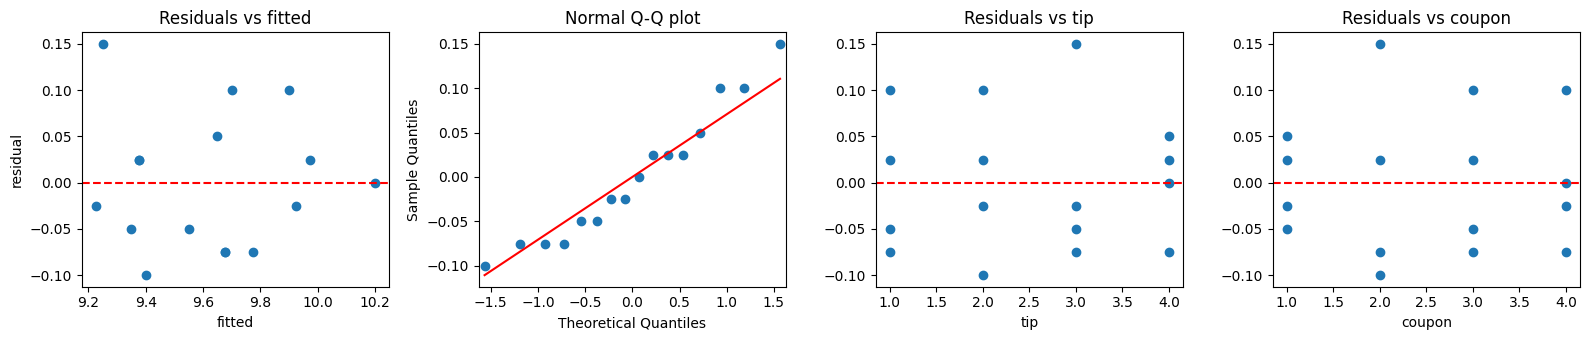

Shapiro-Wilk on residuals: ShapiroResult(statistic=np.float64(0.9395749936061485), pvalue=np.float64(0.3438404924411165))

Tukey's test for nonadditivity (row q_nonadd):


,df,sum_sq,mean_sq,F,PR(>F)
C(Tip),3.0,0.38500,0.12833,13.52306,0.00169
C(Coupon),3.0,0.82500,0.27500,28.97798,0.00012
q_nonadd,1.0,0.00408,0.00408,0.42996,0.53041
Residual,8.0,0.07592,0.00949,NaN,NaN


In [7]:
res, fit = rcbd.resid, rcbd.fittedvalues
fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))
axes[0].scatter(fit, res); axes[0].axhline(0, color="red", ls="--"); axes[0].set(xlabel="fitted", ylabel="residual", title="Residuals vs fitted")
sm.qqplot(res, line="s", ax=axes[1]); axes[1].set_title("Normal Q-Q plot")
axes[2].scatter(hard["Tip"], res); axes[2].axhline(0, color="red", ls="--"); axes[2].set(xlabel="tip", title="Residuals vs tip")
axes[3].scatter(hard["Coupon"], res); axes[3].axhline(0, color="red", ls="--"); axes[3].set(xlabel="coupon", title="Residuals vs coupon")
plt.tight_layout(); plt.show()

print("Shapiro-Wilk on residuals:", stats.shapiro(res))
print("\nTukey's test for nonadditivity (row q_nonadd):")
display(tukey_nonadditivity(hard, "y", "Tip", "Coupon").round(5))

No pattern in the residuals, normality is acceptable and there is no evidence of nonadditivity ($p = 0.53$).

### How many blocks?

We want to detect a true maximum difference of $D = 0.4$ between two tip means with high probability, with
$\sigma = 0.1$. For the least favourable configuration (two means $D$ apart, the others in the middle)
$\lambda = bD^2/(2\sigma^2)$, $\Phi^2 = \lambda/a$, and $F_0 \sim F_{a-1,(a-1)(b-1)}(\lambda)$ under $H_1$.

In [8]:
a, D, sigma = 4, 0.4, 0.1
rows = []
for b in range(3, 9):
    lam = b * D**2 / (2 * sigma**2)
    df1, df2 = a - 1, (a - 1) * (b - 1)
    rows.append({"blocks b": b, "Phi": np.sqrt(lam / a), "lambda": lam, "df2": df2,
                 "power": anova_power(lam, df1, df2)})
display(pd.DataFrame(rows).round(4))

,blocks b,Phi,lambda,df2,power
0,3,2.4495,24.0,6,0.8461
1,4,2.8284,32.0,9,0.9757
2,5,3.1623,40.0,12,0.9972
3,6,3.4641,48.0,15,0.9997
4,7,3.7417,56.0,18,1.0000
5,8,4.0000,64.0,21,1.0000


## 2. Lecture example: battery life (two-factor factorial)

Montgomery, Example 5.1: the effective life (hours) of a battery for three plate materials and three temperatures
(15, 70, 125 $^\circ$F), $n = 4$ replicates, all 36 runs in random order. Questions: what effects do material and
temperature have on life, and is there a material that gives uniformly long life regardless of temperature?

In [9]:
bat = pd.read_csv(URL + "battery.txt", sep=r"\s+")
print(bat.shape)
display(bat.pivot_table(index="Material", columns="Temperature", values="Life", aggfunc="mean"))
display(bat.pivot_table(index="Material", columns="Temperature", values="Life", aggfunc="std").round(2))

(36, 3)


Temperature,15,70,125
Material,,,
1,134.75,57.25,57.5
2,155.75,119.75,49.5
3,144.00,145.75,85.5


Temperature,15,70,125
Material,,,
1,45.35,23.60,26.85
2,25.62,12.66,19.26
3,25.97,22.54,19.28


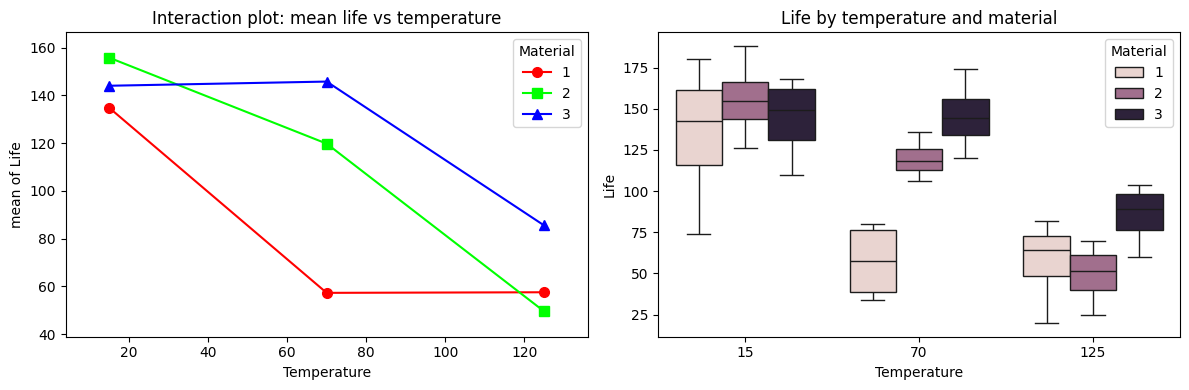

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
interaction_plot(bat["Temperature"], bat["Material"], bat["Life"], ax=axes[0], markers=["o", "s", "^"], ms=7)
axes[0].set_title("Interaction plot: mean life vs temperature")
sns.boxplot(data=bat, x="Temperature", y="Life", hue="Material", ax=axes[1])
axes[1].set_title("Life by temperature and material")
plt.tight_layout(); plt.show()

The lines are not parallel: material 1 loses most of its life already at 70 $^\circ$F, materials 2 and 3 only at 125 $^\circ$F.

### ANOVA with and without interaction

In [11]:
full = smf.ols("Life ~ C(Material) * C(Temperature)", data=bat).fit()
add = smf.ols("Life ~ C(Material) + C(Temperature)", data=bat).fit()
display(sm.stats.anova_lm(full, typ=2))
display(sm.stats.anova_lm(add, typ=2))
print("F-test for the interaction (additive vs full model):")
display(sm.stats.anova_lm(add, full))

,sum_sq,df,F,PR(>F)
C(Material),10683.722222,2.0,7.911372,1.976083e-03
C(Temperature),39118.722222,2.0,28.967692,1.908596e-07
C(Material):C(Temperature),9613.777778,4.0,3.559535,1.861117e-02
Residual,18230.750000,27.0,NaN,NaN


,sum_sq,df,F,PR(>F)
C(Material),10683.722222,2.0,5.947226,0.006515
C(Temperature),39118.722222,2.0,21.775919,0.000001
Residual,27844.527778,31.0,NaN,NaN


F-test for the interaction (additive vs full model):


,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,31.0,27844.527778,0.0,NaN,NaN,NaN
1,27.0,18230.750000,4.0,9613.777778,3.559535,0.018611


### Model adequacy

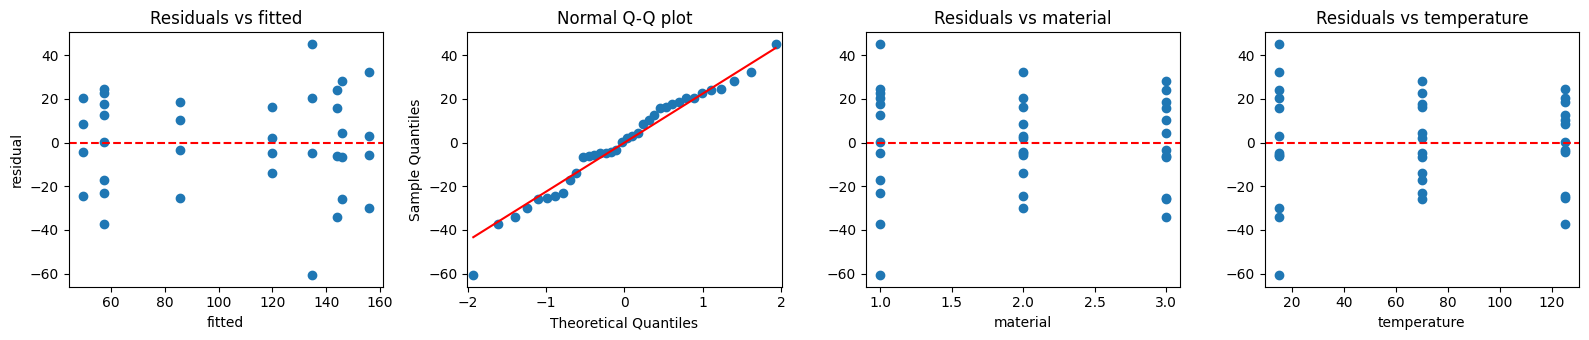

Shapiro-Wilk on residuals: ShapiroResult(statistic=np.float64(0.9760570230871322), pvalue=np.float64(0.6117266783415463))
Levene (Brown-Forsythe) across the 9 cells: LeveneResult(statistic=np.float64(0.7995970449966421), pvalue=np.float64(0.6081330500874305))


In [12]:
res, fit = full.resid, full.fittedvalues
fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))
axes[0].scatter(fit, res); axes[0].axhline(0, color="red", ls="--"); axes[0].set(xlabel="fitted", ylabel="residual", title="Residuals vs fitted")
sm.qqplot(res, line="s", ax=axes[1]); axes[1].set_title("Normal Q-Q plot")
axes[2].scatter(bat["Material"], res); axes[2].axhline(0, color="red", ls="--"); axes[2].set(xlabel="material", title="Residuals vs material")
axes[3].scatter(bat["Temperature"], res); axes[3].axhline(0, color="red", ls="--"); axes[3].set(xlabel="temperature", title="Residuals vs temperature")
plt.tight_layout(); plt.show()

cells_ = [g["Life"].to_numpy(dtype=float) for _, g in bat.groupby(["Material", "Temperature"])]
print("Shapiro-Wilk on residuals:", stats.shapiro(res))
print("Levene (Brown-Forsythe) across the 9 cells:", stats.levene(*cells_))

The residual plots show slightly larger spread for material 1 at 15 $^\circ$F (one low observation, 74 h), but no serious
violation of the assumptions.

### Comparisons of means

Tukey's HSD for the main effects uses $MS_E = 675.2$ with 27 df from the full model. Because the interaction is significant,
the main-effect comparisons average over very different situations; the **simple effects** (materials compared at a fixed
temperature, $n = 4$ per cell, pooled $MS_E$) answer the practical question.

In [13]:
display(tukey_from_model(full, bat, "Material", "Life").round(4))
display(tukey_from_model(full, bat, "Temperature", "Life").round(4))

MS_E = 675.2, df_E = 27, n per level = 12, HSD = 26.3


,pair,diff,lower,upper,p_adj,reject
0,2 - 1,25.1667,-1.1357,51.4690,0.0628,False
1,3 - 1,41.9167,15.6143,68.2190,0.0014,True
2,3 - 2,16.7500,-9.5523,43.0523,0.2718,False


MS_E = 675.2, df_E = 27, n per level = 12, HSD = 26.3


,pair,diff,lower,upper,p_adj,reject
0,70 - 15,-37.2500,-63.5523,-10.9477,0.0044,True
1,125 - 15,-80.6667,-106.9690,-54.3643,0.0000,True
2,125 - 70,-43.4167,-69.7190,-17.1143,0.0010,True


In [14]:
mse, dfe = full.mse_resid, full.df_resid
T = stats.studentized_range.ppf(0.95, 3, dfe) * np.sqrt(mse / 4)
print(f"Critical difference for materials within one temperature: T = {T:.2f}")
rows = []
for temp, sub in bat.groupby("Temperature"):
    m = sub.groupby("Material")["Life"].mean()
    for i, j in [(1, 2), (1, 3), (2, 3)]:
        rows.append({"Temperature": temp, "pair": f"{j} - {i}", "diff": m[j] - m[i], "significant": abs(m[j] - m[i]) > T})
pd.DataFrame(rows).pivot(index="Temperature", columns="pair", values="diff")

Critical difference for materials within one temperature: T = 45.56


pair,2 - 1,3 - 1,3 - 2
Temperature,,,
15,21.0,9.25,-11.75
70,62.5,88.50,26.00
125,-8.0,28.00,36.00


The materials differ only at 70 $^\circ$F (materials 2 and 3 better than 1). Material 3 gives long life at all three temperatures,
so it is the most robust choice.

### Sample size

How many replicates are needed to detect a difference of $D = 40$ h between two material means with $\sigma = 25$ h?
For factor $A$: $\Phi^2 = nbD^2/(2a\sigma^2)$, $\lambda = a\Phi^2$, $\nu_1 = a-1$, $\nu_2 = ab(n-1)$.

In [15]:
a = b = 3
D, sigma = 40, 25
rows = []
for n in [2, 3, 4, 5]:
    lam = n * b * D**2 / (2 * sigma**2)
    rows.append({"n": n, "Phi": np.sqrt(lam / a), "lambda": lam, "df2": a * b * (n - 1),
                 "power": anova_power(lam, a - 1, a * b * (n - 1))})
display(pd.DataFrame(rows).round(3))

,n,Phi,lambda,df2,power
0,2,1.600,7.68,9,0.542
1,3,1.960,11.52,18,0.803
2,4,2.263,15.36,27,0.923
3,5,2.530,19.20,36,0.972


### Response curves

Temperature is quantitative. With three levels we can fit at most a quadratic in temperature; letting the linear and
quadratic terms interact with material decomposes $SS_{Temperature}$ and $SS_{Material:Temperature}$ into single-degree-of-freedom parts.

,df,sum_sq,mean_sq,F,PR(>F)
C(Material),2.0,10683.722222,5341.861111,7.911372,1.976083e-03
T,1.0,39042.666667,39042.666667,57.822745,3.525248e-08
C(Material):T,2.0,2315.083333,1157.541667,1.714336,1.991088e-01
I(T ** 2),1.0,76.055556,76.055556,0.112639,7.397530e-01
C(Material):I(T ** 2),2.0,7298.694444,3649.347222,5.404735,1.061214e-02
Residual,27.0,18230.750000,675.212963,NaN,NaN


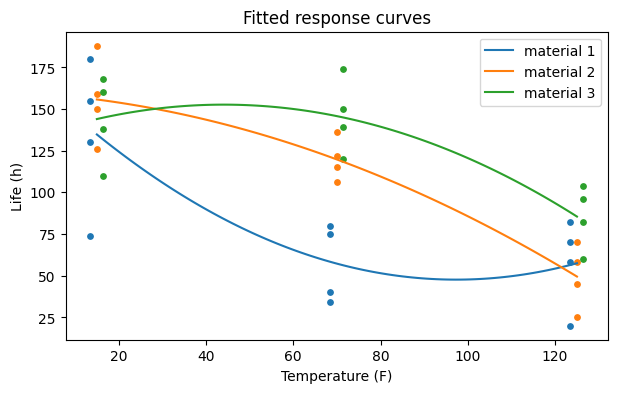

In [16]:
bat["T"] = bat["Temperature"].astype(float)
rc = smf.ols("Life ~ C(Material) + T + I(T**2) + C(Material):T + C(Material):I(T**2)", data=bat).fit()
display(sm.stats.anova_lm(rc, typ=1))

grid = np.linspace(15, 125, 100)
fig, ax = plt.subplots(figsize=(7, 4))
for mat, colour in zip([1, 2, 3], ["C0", "C1", "C2"]):
    pred = rc.predict(pd.DataFrame({"Material": mat, "T": grid}))
    ax.plot(grid, pred, color=colour, label=f"material {mat}")
    sub = bat[bat["Material"] == mat]
    ax.scatter(sub["T"] + (mat - 2) * 1.5, sub["Life"], color=colour, s=15)
ax.set(xlabel="Temperature (F)", ylabel="Life (h)", title="Fitted response curves")
ax.legend(); plt.show()

## 3. Lecture examples: blocking in a factorial, three factors, response surface

### Radar target detection (Example 5.6): a factorial run in blocks

Factors: filter type (2) and ground clutter (low, medium, high). Each of four operators runs all six combinations in
random order, so the operator is a **block**. The model is $y_{ijk} = \mu + \tau_i + \beta_j + (\tau\beta)_{ij} + \delta_k + \varepsilon_{ijk}$.

With operators as blocks


,sum_sq,df,F,PR(>F)
C(Operator),402.166667,3.0,12.089178,2.771485e-04
C(Filter),1066.666667,1.0,96.192385,6.446793e-08
C(Ground),335.583333,2.0,15.131513,2.527013e-04
C(Filter):C(Ground),77.083333,2.0,3.475701,5.750655e-02
Residual,166.333333,15.0,NaN,NaN


Blocks ignored


,sum_sq,df,F,PR(>F)
C(Filter),1066.666667,1.0,33.773087,0.000017
C(Ground),335.583333,2.0,5.312665,0.015371
C(Filter):C(Ground),77.083333,2.0,1.220317,0.318422
Residual,568.500000,18.0,NaN,NaN


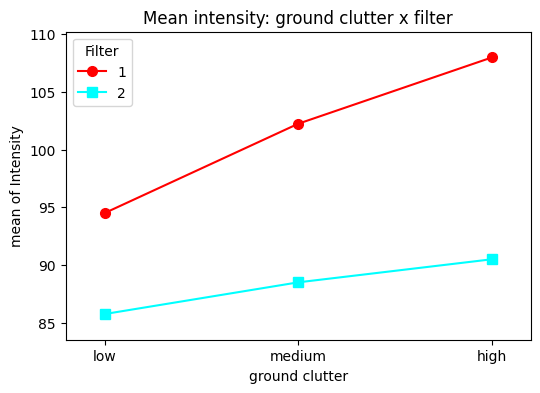

In [17]:
radar = pd.read_csv(URL + "intensity.txt", sep=r"\s+")
radar["Ground"] = pd.Categorical(radar["Ground"], categories=["low", "medium", "high"], ordered=True)
blk = smf.ols("Intensity ~ C(Operator) + C(Filter) * C(Ground)", data=radar).fit()
noblk = smf.ols("Intensity ~ C(Filter) * C(Ground)", data=radar).fit()
print("With operators as blocks"); display(sm.stats.anova_lm(blk, typ=2))
print("Blocks ignored"); display(sm.stats.anova_lm(noblk, typ=2))

fig, ax = plt.subplots(figsize=(6, 4))
interaction_plot(radar["Ground"].cat.codes, radar["Filter"], radar["Intensity"], ax=ax, markers=["o", "s"], ms=7)
ax.set_xticks([0, 1, 2], radar["Ground"].cat.categories)
ax.set(xlabel="ground clutter", title="Mean intensity: ground clutter x filter"); plt.show()

### Soft drink bottling (Example 5.3): three factors

Deviation from the target fill height for carbonation (10, 12, 14 %), operating pressure (25, 30 psi) and line speed
(200, 250 bottles/min), two replicates.

,sum_sq,df,F,PR(>F)
C(Carbonation),252.750000,2.0,178.411765,1.186249e-09
C(Pressure),45.375000,1.0,64.058824,3.742257e-06
C(Speed),22.041667,1.0,31.117647,1.202174e-04
C(Carbonation):C(Pressure),5.250000,2.0,3.705882,5.580812e-02
C(Carbonation):C(Speed),0.583333,2.0,0.411765,6.714939e-01
C(Pressure):C(Speed),1.041667,1.0,1.470588,2.485867e-01
C(Carbonation):C(Pressure):C(Speed),1.083333,2.0,0.764706,4.868711e-01
Residual,8.500000,12.0,NaN,NaN


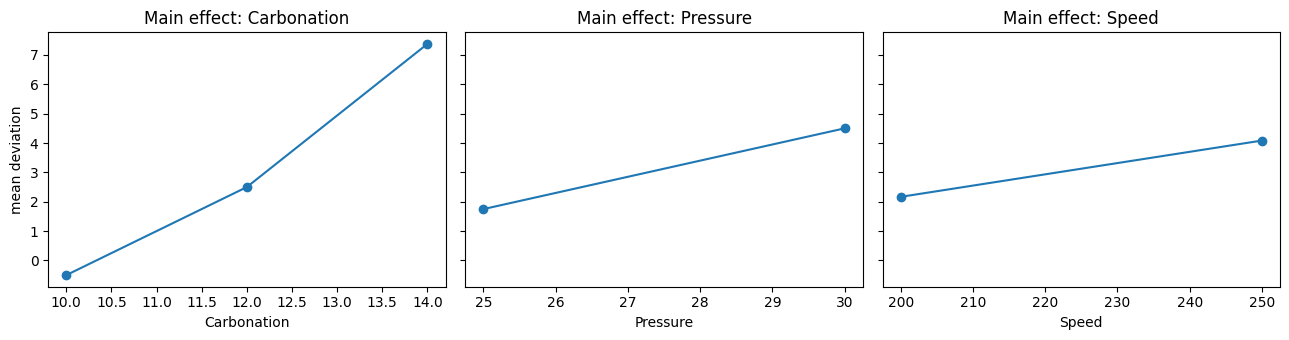

In [18]:
bot = pd.read_csv(URL + "bottling.txt", sep=r"\s+")
m3 = smf.ols("Deviation ~ C(Carbonation) * C(Pressure) * C(Speed)", data=bot).fit()
display(sm.stats.anova_lm(m3, typ=2))

fig, axes = plt.subplots(1, 3, figsize=(13, 3.5), sharey=True)
for ax, factor in zip(axes, ["Carbonation", "Pressure", "Speed"]):
    bot.groupby(factor)["Deviation"].mean().plot(marker="o", ax=ax)
    ax.set_title(f"Main effect: {factor}"); ax.set_ylabel("mean deviation")
plt.tight_layout(); plt.show()

### Tool life (Example 5.5): response surface for two quantitative factors

Cutting angle (15, 20, 25 degrees) and cutting speed (125, 150, 175 in/min), two replicates. The full model with linear and
quadratic terms in both factors and all their products has 9 parameters, one per cell mean.

,df,sum_sq,mean_sq,F,PR(>F)
Angle,1.0,8.333333,8.333333,5.769231,0.039772
I(Angle ** 2),1.0,16.000000,16.000000,11.076923,0.008824
Speed,1.0,21.333333,21.333333,14.769231,0.003948
I(Speed ** 2),1.0,4.000000,4.000000,2.769231,0.130451
Angle:Speed,1.0,8.000000,8.000000,5.538462,0.043065
Angle:I(Speed ** 2),1.0,42.666667,42.666667,29.538462,0.000414
I(Angle ** 2):Speed,1.0,2.666667,2.666667,1.846154,0.207306
I(Angle ** 2):I(Speed ** 2),1.0,8.000000,8.000000,5.538462,0.043065
Residual,9.0,13.000000,1.444444,NaN,NaN


Intercept                     -1067.999999
Angle                           136.300000
I(Angle ** 2)                    -4.080000
Speed                            14.480000
I(Speed ** 2)                    -0.049600
Angle:Speed                      -1.864000
Angle:I(Speed ** 2)               0.006400
I(Angle ** 2):Speed               0.056000
I(Angle ** 2):I(Speed ** 2)      -0.000192
dtype: float64


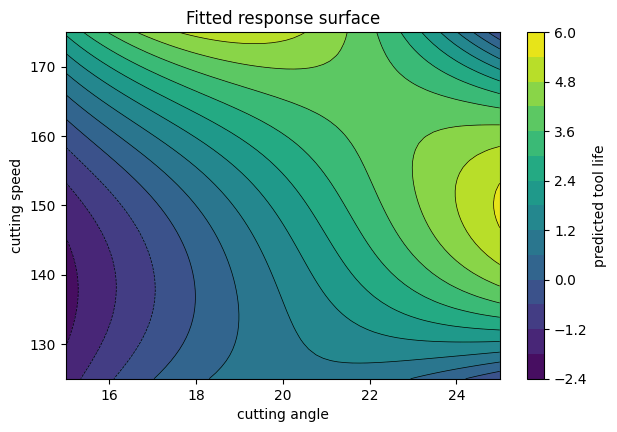

In [19]:
tool = pd.read_csv(URL + "toollife.txt", sep=r"\s+")
rs = smf.ols("Life ~ (Angle + I(Angle**2)) * (Speed + I(Speed**2))", data=tool).fit()
display(sm.stats.anova_lm(rs, typ=1))
print(rs.params.round(6))

A, S = np.meshgrid(np.linspace(15, 25, 60), np.linspace(125, 175, 60))
Z = rs.predict(pd.DataFrame({"Angle": A.ravel(), "Speed": S.ravel()})).to_numpy().reshape(A.shape)
fig, ax = plt.subplots(figsize=(7, 4.5))
cs = ax.contourf(A, S, Z, levels=12, cmap="viridis")
ax.contour(A, S, Z, levels=12, colors="k", linewidths=0.5)
fig.colorbar(cs, label="predicted tool life")
ax.set(xlabel="cutting angle", ylabel="cutting speed", title="Fitted response surface")
plt.show()

## In-class problems

Work in pairs; we discuss the results at the end of the class. For every test state the hypotheses, the test statistic,
the $p$-value and your decision.

### Problem 4.3 (with 4.16): chemical agents and cloth strength

A chemist wishes to test the effect of four chemical agents on the strength of a particular type of cloth. Because there might
be variability from one bolt to another, the chemist decides to use a randomized block design, with the bolts of cloth
considered as blocks. She selects five bolts and applies all four chemicals in random order to each bolt.
The resulting tensile strengths are:

| Chemical | Bolt 1 | Bolt 2 | Bolt 3 | Bolt 4 | Bolt 5 |
|---|---|---|---|---|---|
| 1 | 73 | 68 | 74 | 71 | 67 |
| 2 | 73 | 67 | 75 | 72 | 70 |
| 3 | 75 | 68 | 78 | 73 | 68 |
| 4 | 73 | 71 | 75 | 75 | 69 |

In [20]:
strength = [[73, 68, 74, 71, 67],
            [73, 67, 75, 72, 70],
            [75, 68, 78, 73, 68],
            [73, 71, 75, 75, 69]]
cloth = pd.DataFrame([(c + 1, b + 1, strength[c][b]) for c in range(4) for b in range(5)],
                     columns=["Chemical", "Bolt", "Strength"])
cloth.pivot(index="Chemical", columns="Bolt", values="Strength")

Bolt,1,2,3,4,5
Chemical,,,,,
1,73,68,74,71,67
2,73,67,75,72,70
3,75,68,78,73,68
4,73,71,75,75,69


**Question 1.** Plot the data (strength versus bolt, one line per chemical). What do you expect from the analysis?

In [21]:
# TODO: add your analysis here

**Question 2.** Analyse the data as an RCBD with $\alpha = 0.05$. Do the chemicals differ?

In [22]:
# TODO: add your analysis here

**Question 3.** (Problem 4.16) Assuming that chemical types and bolts are fixed, estimate the model parameters $\tau_i$ and $\beta_j$.

In [23]:
# TODO: add your analysis here

**Question 4.** Analyse the same data as if they came from a completely randomized design. Compare the error mean squares and compute the relative efficiency of the RCBD. Was blocking worthwhile?

In [24]:
# TODO: add your analysis here

**Question 5.** Analyse the residuals and perform Tukey's test for nonadditivity. Comment on model adequacy.

In [25]:
# TODO: add your analysis here

### Problems 5.4, 5.5 and 5.34: surface finish of a metal part

An engineer suspects that the surface finish of a metal part is influenced by the feed rate and the depth of cut. He selects
three feed rates (0.20, 0.25, 0.30 in/min) and four depths of cut (0.15, 0.18, 0.20, 0.25 in), and runs a factorial experiment
with three replicates.

In [26]:
finish = pd.read_csv(URL + "Chapter5_Pr02.csv", sep=";")
finish.columns = ["Depth", "Feed", "Finish"]
display(finish.pivot_table(index="Feed", columns="Depth", values="Finish", aggfunc=list))

Depth,0.15,0.18,0.20,0.25
Feed,,,,
0.20,"[74, 64, 60]","[79, 68, 73]","[82, 88, 92]","[99, 104, 96]"
0.25,"[92, 86, 88]","[98, 104, 88]","[99, 108, 95]","[104, 110, 99]"
0.30,"[99, 98, 102]","[104, 99, 95]","[108, 110, 99]","[114, 107, 111]"


**Question 1.** Draw an interaction plot. Then analyse the data and draw conclusions; report the $p$-values ($\alpha = 0.05$).

In [27]:
# TODO: add your analysis here

**Question 2.** Prepare appropriate residual plots and comment on the model's adequacy.

In [28]:
# TODO: add your analysis here

**Question 3.** Obtain point estimates of the mean surface finish at each feed rate.

In [29]:
# TODO: add your analysis here

**Question 4.** (Problem 5.5) Compute a 95 percent confidence interval for the mean difference in response for feed rates of 0.20 and 0.25 in/min.

In [30]:
# TODO: add your analysis here

**Question 5.** (Problem 5.34) Suppose that the experiment had been conducted in three blocks, with each replicate a block.
The observations in the data table are given in order: the first observation in each cell comes from the first replicate, and so on.
Reanalyse the data as a factorial experiment in blocks and estimate the variance component for blocks,
$\hat\sigma^2_{Block} = (MS_{Blocks} - MS_E)/(ab)$. Does blocking appear to be useful?

In [31]:
# Hint: finish["Block"] = finish.groupby(["Feed", "Depth"]).cumcount() + 1
# TODO: add your analysis here

**Question 6.** Depth of cut is quantitative. Fit a model with linear and quadratic terms in depth (interacting with feed rate as a factor). Is a curvature in depth needed?

In [32]:
# TODO: add your analysis here

### Problem 5.15: two factors, one observation per cell

Analyse the following data from a two-factor factorial experiment and draw conclusions. Perform a test for nonadditivity
($\alpha = 0.05$).

| Row factor | Column 1 | Column 2 | Column 3 | Column 4 |
|---|---|---|---|---|
| 1 | 36 | 39 | 36 | 32 |
| 2 | 18 | 20 | 22 | 20 |
| 3 | 30 | 37 | 33 | 34 |

In [33]:
p515 = pd.read_csv(URL + "Chapter5_Pr13.csv", sep=";")
p515.pivot(index="Row", columns="Column", values="Data")

Column,1,2,3,4
Row,,,,
1,36,39,36,32
2,18,20,22,20
3,30,37,33,34


**Question 1.** Fit the additive model and test the main effects.

In [34]:
# TODO: add your analysis here

**Question 2.** Perform Tukey's test for nonadditivity. What does the result mean for the conclusions of Question 1?

In [35]:
# TODO: add your analysis here

## Assignment

* Run the notebook above and make sure you understand each step.
* Solve the following problems from Montgomery, *Design and Analysis of Experiments* (8th edition): **4.21, 5.8 with 5.23, 5.18 and 5.20**.
  Start in class and finish at home.
* For every test state the hypotheses, report the test statistic, its $p$-value and your decision; for comparisons of means
  say which procedure and which error mean square you use; check the assumptions with residual plots; end each problem with
  a conclusion in one or two sentences.
* Submit your solved notebook as a pull request into the `HW/` folder of the course repository, named
  `HW/01NAEX_Ex03_HW_<Surname>.ipynb` (see `HW/README.md`). **Deadline: Sunday 18 October 2026** (the next lecture is on 19 October).

### Problem 4.21: eye focus time

An industrial engineer is conducting an experiment on eye focus time. He is interested in the effect of the distance of the
object from the eye on the focus time. Four different distances are of interest. He has five subjects available for the
experiment. Because there may be differences among individuals, he decides to conduct the experiment in a randomized block design.

| Distance (ft) | Subject 1 | Subject 2 | Subject 3 | Subject 4 | Subject 5 |
|---|---|---|---|---|---|
| 4 | 10 | 6 | 6 | 6 | 6 |
| 6 | 7 | 6 | 6 | 1 | 6 |
| 8 | 5 | 3 | 3 | 2 | 5 |
| 10 | 6 | 4 | 4 | 2 | 3 |

In [36]:
focus_time = [[10, 6, 6, 6, 6],
              [7, 6, 6, 1, 6],
              [5, 3, 3, 2, 5],
              [6, 4, 4, 2, 3]]
distances = [4, 6, 8, 10]
focus = pd.DataFrame([(distances[d], s + 1, focus_time[d][s]) for d in range(4) for s in range(5)],
                     columns=["Distance", "Subject", "Time"])
focus.pivot(index="Distance", columns="Subject", values="Time")

Subject,1,2,3,4,5
Distance,,,,,
4,10,6,6,6,6
6,7,6,6,1,6
8,5,3,3,2,5
10,6,4,4,2,3


**Question 1.** Analyse the data ($\alpha = 0.05$) and draw appropriate conclusions.

In [37]:
# TODO: add your analysis here

**Question 2.** Which distances differ? Use Tukey's HSD with the error mean square of the RCBD.

In [38]:
# TODO: add your analysis here

**Question 3.** Analyse the residuals and perform Tukey's test for nonadditivity.

In [39]:
# TODO: add your analysis here

**Question 4.** Reanalyse the data ignoring the subjects (completely randomized design) and compute the relative efficiency of the RCBD. Was blocking on subjects worthwhile?

In [40]:
# TODO: add your analysis here

**Question 5.** Assume that the subjects are a random sample of people. Estimate the block variance component $\hat\sigma^2_\beta = (MS_{Blocks} - MS_E)/a$.

In [41]:
# TODO: add your analysis here

### Problems 5.8 and 5.23: breaking strength of a synthetic fibre

The factors that influence the breaking strength of a synthetic fibre are being studied. Four production machines and three
operators are chosen and a factorial experiment is run using fibre from the same production batch; two replicates.

In [42]:
fibre = pd.read_csv(URL + "Chapter5_Pr06.csv", sep=";")
display(fibre.pivot_table(index="Operator", columns="Machine", values="Strength", aggfunc=list))

Machine,1,2,3,4
Operator,,,,
1,"[109, 110]","[110, 115]","[108, 109]","[110, 108]"
2,"[110, 112]","[110, 111]","[111, 109]","[114, 112]"
3,"[116, 114]","[112, 115]","[114, 119]","[120, 117]"


**Question 1.** Draw an interaction plot, analyse the data and draw conclusions ($\alpha = 0.05$).

In [43]:
# TODO: add your analysis here

**Question 2.** Prepare appropriate residual plots and comment on the model's adequacy.

In [44]:
# TODO: add your analysis here

**Question 3.** (Problem 5.23) Analyse the data assuming that the two replicates are blocks (the first observation in each cell
comes from the first replicate). Estimate the variance component for blocks. Does blocking change the conclusions?

In [45]:
# TODO: add your analysis here

### Problem 5.18: strength of paper (three factors)

The percentage of hardwood concentration in raw pulp (2, 4, 8 %), the vat pressure (400, 500, 650) and the cooking time of the
pulp (3.0, 4.0 hours) are being investigated for their effects on the strength of paper. A factorial experiment with two
replicates is conducted.

In [46]:
paper = pd.read_csv(URL + "Chapter5_Pr16.csv", sep=";")
display(paper.pivot_table(index=["Cooking_Time", "Hardwood"], columns="Pressure", values="Strength", aggfunc=list))

Pressure                          400             500             650
Cooking_Time Hardwood                                                
3            2         [196.6, 196.0]  [197.7, 196.0]  [199.8, 199.4]
             4         [198.5, 197.2]  [196.0, 196.9]  [198.4, 197.6]
             8         [197.5, 196.6]  [195.6, 196.2]  [197.4, 198.1]
4            2         [198.4, 198.6]  [199.6, 200.4]  [200.6, 200.9]
             4         [197.5, 198.1]  [198.7, 198.0]  [199.6, 199.0]
             8         [197.6, 198.4]  [197.0, 197.8]  [198.5, 199.8]

**Question 1.** Analyse the data and draw conclusions ($\alpha = 0.05$). Use plots of the main effects and of the important interactions.

In [47]:
# TODO: add your analysis here

**Question 2.** Prepare appropriate residual plots and comment on the model's adequacy.

In [48]:
# TODO: add your analysis here

**Question 3.** Under what set of conditions would you operate this process? Why?

In [49]:
# TODO: add your analysis here

### Problem 5.20: number of replicates (data of Problem 5.3)

The yield of a chemical process is studied at three pressures (200, 215, 230 psig) and three temperatures (150, 160, 170 $^\circ$C),
with two replicates (Problem 5.3).

In [50]:
yield_ = pd.read_csv(URL + "Chapter5_Pr01.csv", sep=";")
display(yield_.pivot_table(index="Temperature", columns="Pressure", values="Yield", aggfunc=list))

Pressure,200,215,230
Temperature,,,
150,"[90.4, 90.2]","[90.7, 90.6]","[90.2, 90.4]"
160,"[90.1, 90.3]","[90.5, 90.6]","[89.9, 90.1]"
170,"[90.5, 90.7]","[90.8, 90.9]","[90.1, 90.4]"


**Question 1.** (Problem 5.3) Analyse the data and draw conclusions ($\alpha = 0.05$).

In [51]:
# TODO: add your analysis here

**Question 2.** (Problem 5.20) We wish to reject the null hypothesis with a high probability if the difference in the true mean
yield at any two pressures is as great as 0.5. If a reasonable prior estimate of the standard deviation of yield is 0.1,
how many replicates should be run? Compute the power for $n = 2, 3, 4$ with `anova_power()`.

In [52]:
# TODO: add your analysis here

**Question 3.** Repeat Question 2 with $\sigma$ estimated from the data of Problem 5.3 ($\hat\sigma = \sqrt{MS_E}$) and with a difference of 0.25. How sensitive is the required $n$ to these inputs?

In [53]:
# TODO: add your analysis here